# Macroeconomic Forecasting: Comparing Traditional and Advanced Models

## Background and Motivation

In the current literature of macroeconomic forecasting, **advanced forecasting models** that leverage neural networks outperform traditional econometric models due to their ability to learn complex relationships between predictor variables. However, traditional econometric models are still preferred due to their **high interpretability** compared to advanced machine learning methods which are black boxes.

## Research Design

In this analysis, we experiment with two distinct modeling approaches:

- **Vector Autoregression (VAR)**: A traditional econometric model
- **Long-Short-Term Memory (LSTM)**: An advanced machine learning method

## Understanding Macroeconomic Indicators

In macroeconomic forecasting, it is crucial to identify the type of macroeconomic indicator. Indicators are classified into three categories:

### 📈 Leading Indicators
Predict future economic conditions, which is most helpful for improving the accuracy of time series forecasting

### 📊 Coincident Indicators  
Offer a real-time snapshot of the economy's current state

### 📉 Lagging Indicators
Provide historical context and confirm established trends

---

## Methodology

We compare the performance of both models while analyzing the indicators that contribute to model performance.

> **Research Objective**: Compare VAR and LSTM performance while unpacking the indicators that drive predictive accuracy for each target variable.

---

*This notebook explores the trade-off between model complexity and interpretability in macroeconomic forecasting applications.*

In [57]:
# =========================
# 1) Imports & Configuration
# =========================
import os, requests, numpy as np, pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
import pandas as pd
import warnings

# Forecasting GDP growth rates

In [2]:
FRED_API_KEY = os.getenv("FRED_API_KEY", "YOUR_FRED_API_KEY_HERE")
BASE_URL = "https://api.stlouisfed.org/fred/series/observations"
COMMON_PARAMS = {"api_key": FRED_API_KEY, "file_type": "json", "observation_start": "1970-01-01"}

In [3]:
# ---- Target & Predictors ----
TARGET_ID = "GDPC1"  # Real GDP (quarterly)
FEATURE_IDS = {
    # Leading / early-cycle
    "HOUST":      "Housing Starts",
    "PERMIT":     "Building Permits",
    "UMCSENT":    "U. Michigan Sentiment",
    "T10Y3M":     "10Y-3M Term Spread",
    "DCOILWTICO": "WTI Crude Oil (USD/bbl)",

    # Coincident
    "INDPRO": "Industrial Production",
    "RSXFS":  "Retail & Food Services Sales",
    "PAYEMS": "Nonfarm Payrolls",
    "UNRATE": "Unemployment Rate",

    # Financial & money
    "BAA10Y":   "BAA - 10Y Treasury Spread",
    "FEDFUNDS": "Effective Fed Funds Rate",
    "M2SL":     "M2 Money Stock",
}

# Transform recipe per series (after converting to quarterly mean for monthly/daily):
#   - 'logdiff_ann' : 400*log(x_t/x_{t-1})  (QoQ annualized growth, for quarterlies)
#   - 'diff'        : first difference (levels like rates if desired)
#   - 'level'       : use level (e.g., rates/spreads/sentiment/unemp)
TRANSFORMS = {
    "GDPC1":     "logdiff_ann",     # target: GDP growth (QoQ annualized)
    # Leading / early-cycle
    "HOUST":     "logdiff_ann",
    "PERMIT":    "logdiff_ann",
    "UMCSENT":   "level",
    "T10Y3M":    "level",
    "DCOILWTICO":"logdiff_ann",
    # Coincident
    "INDPRO":    "logdiff_ann",
    "RSXFS":     "logdiff_ann",
    "PAYEMS":    "logdiff_ann",
    "UNRATE":    "level",
    # Financial & money
    "BAA10Y":    "level",
    "FEDFUNDS":  "level",
    "M2SL":      "logdiff_ann",
}

In [ ]:
# =========================
# 2) FRED Fetch & Quarterly Transform
# =========================
def fetch_fred_series(series_id: str) -> pd.Series:
    params = COMMON_PARAMS | {"series_id": series_id}
    r = requests.get(BASE_URL, params=params); r.raise_for_status()
    obs = r.json()["observations"]
    idx, vals = [], []
    for o in obs:
        v = o["value"]
        if v == ".":
            continue
        try:
            vals.append(float(v)); idx.append(pd.to_datetime(o["date"]))
        except:
            continue
    return pd.Series(vals, index=pd.DatetimeIndex(idx), name=series_id).sort_index()

# Pull
gdp_q = fetch_fred_series(TARGET_ID)        # quarterly already
series_q = {"GDPC1": gdp_q}
for sid in FEATURE_IDS:
    s = fetch_fred_series(sid)
    # resample to quarterly mean (works for monthly/daily/weekly)
    series_q[sid] = s.resample("QS").mean()

# Combine & align
df_q = pd.concat(series_q.values(), axis=1) # Lines up the series by their DatetimeIndex, GDP's DatetimeIndex is QS
df_q.columns = list(series_q.keys())
df_q = df_q.dropna()

In [63]:
# =========================
# 3) Economic Transforms
# =========================
def qoq_ann_log_growth(x: pd.Series) -> pd.Series:
    return 100.0 * np.log(x / x.shift(1))

def apply_transform(df: pd.DataFrame, plan: dict) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    for col, kind in plan.items():
        if kind == "logdiff_ann":
            out[col] = qoq_ann_log_growth(df[col])
        elif kind == "diff":
            out[col] = df[col].diff()
        elif kind == "level":
            out[col] = df[col]
        else:
            raise ValueError(f"Unknown transform for {col}: {kind}")
    return out.dropna()

df_t = apply_transform(df_q, TRANSFORMS)

COVID_START_Q = "2020Q1"
COVID_END_Q   = "2021Q4"
DROP_AFTER    = 1   # optionally also remove the first N quarters after COVID to avoid rebound contamination

def drop_quarter_window(df: pd.DataFrame, start_q: str, end_q: str, drop_next: int = 0) -> pd.DataFrame:
    p = df.index.to_period("Q")
    keep = (p < start_q) | (p > end_q)
    out = df.loc[keep].copy()
    if drop_next > 0:
        p2 = out.index.to_period("Q")
        endP = pd.Period(end_q, freq="Q")
        to_drop = [endP + i for i in range(1, drop_next + 1)]
        out = out.loc[~p2.isin(to_drop)]
    return out

df_t = drop_quarter_window(df_t, COVID_START_Q, COVID_END_Q, drop_next=DROP_AFTER)
df_t = drop_quarter_window(df_t, "2007Q4", "2009Q2", drop_next=DROP_AFTER)

print("After 2008 Financial Crisis and COVID drop:", df_t.index.min(), "→", df_t.index.max(), "| n=", len(df_t))

# Target & features
y_name = "GDPC1"  # transformed GDP growth series name
X_names = [c for c in df_t.columns if c != y_name]

# Train/val/test split (time-based)
n = len(df_t)
train_end = int(0.8 * n)
val_end   = int(0.9 * n)
df_tr, df_va, df_te = df_t.iloc[:train_end], df_t.iloc[train_end:val_end], df_t.iloc[val_end:]
print("Train:", df_tr.index.min(), "→", df_tr.index.max())
print("Val:  ", df_va.index.min(), "→", df_va.index.max())
print("Test: ", df_te.index.min(), "→", df_te.index.max())

After 2008 Financial Crisis and COVID drop: 1992-04-01 00:00:00 → 2025-04-01 00:00:00 | n= 116
Train: 1992-04-01 00:00:00 → 2017-01-01 00:00:00
Val:   2017-04-01 00:00:00 → 2022-04-01 00:00:00
Test:  2022-07-01 00:00:00 → 2025-04-01 00:00:00


# 1. Forecasting with VAR

In [64]:
# ===== Helpers =====
def rmse(a, f):
    a = np.asarray(a, float); f = np.asarray(f, float)
    return float(np.sqrt(np.mean((a - f)**2)))

def var_roll_1step(res, history_df, future_index):
    p = res.k_ar
    hist = history_df.copy()
    out = []
    for t in future_index:
        last = hist.values[-p:]
        yhat = res.forecast(last, steps=1)[0]
        row = pd.Series(yhat, index=hist.columns, name=t)
        hist = pd.concat([hist, row.to_frame().T])
        out.append(row)
    return pd.DataFrame(out)

def granger_rank_train(df_train, y_name, X_names, maxlag=4, alpha=0.10, top_n=8):
    """Rank X_names by min SSR-F p-value in bivariate Granger tests (x -> y), on TRAIN only."""
    results = []
    for x in X_names:
        sub = df_train[[y_name, x]].dropna()
        if len(sub) <= maxlag + 8:
            continue
        try:
            # statsmodels expects the first column is the dependent variable
            gc = grangercausalitytests(sub, maxlag=maxlag)
            min_p = min(gc[L][0]['ssr_ftest'][1] for L in gc.keys())
            results.append((x, float(min_p)))
        except Exception:
            # skip ill-behaved series
            continue
    # sort by p-value asc
    results.sort(key=lambda z: z[1])
    # keep those passing alpha, else fallback to top_n
    selected = [x for x,p in results if p < alpha]
    if not selected:
        selected = [x for x,_ in results[:top_n]]
    # return both list and table if you want to inspect
    return selected, pd.DataFrame(results, columns=["variable","p_value"])

# ===== 1) Build base panels from your split =====
# df_tr, df_va, df_te come from your earlier steps (after transforms & any drops)
base_train = df_tr[[y_name] + X_names]
base_val   = df_va[[y_name] + X_names]
base_test  = df_te[[y_name] + X_names]

# ===== 2) Granger screening on TRAIN only =====
TOP_N      = 8
MAXLAG_GC  = 4
gc_keep, gc_table = granger_rank_train(base_train, y_name, X_names, maxlag=MAXLAG_GC, alpha=0.10, top_n=TOP_N)
print("Granger-selected predictors:", gc_keep)

# (optional) inspect top p-values
print(gc_table.head(12))

# Rebuild with selected variables only
use_cols  = [y_name] + gc_keep
var_train = df_tr[use_cols].dropna()
var_val   = df_va[use_cols].dropna()
var_test  = df_te[use_cols].dropna()

# ===== 3) Choose p by validation RMSE over a small grid (respect feasibility) =====
T = len(var_train)
k = var_train.shape[1]
# rough feasibility cap: p < (T-1)/(k+1)
p_cap = max(1, int((T - 1) // (k + 1)))
P_GRID = tuple(p for p in (1,2,3,4) if p <= p_cap) or (1,)
print(f"Training dims after screening: T={T}, k={k}, feasible cap={p_cap}, grid={P_GRID}")

scores = {}
fits = {}
for p in P_GRID:
    try:
        fit = VAR(var_train).fit(p, trend='c')
        pred_val = var_roll_1step(fit, var_train, var_val.index)
        scores[p] = rmse(var_val[y_name], pred_val[y_name])
        fits[p] = fit
    except Exception:
        continue

if not scores:
    raise RuntimeError("No feasible lag in P_GRID; shrink TOP_N or reduce maxlag in GC.")

best_p = min(scores, key=scores.get)
print("Validation RMSE by p:", {p: round(r,3) for p,r in scores.items()}, "| chosen p:", best_p)

# ===== 4) Refit on train+val with chosen p and evaluate on test =====
trainval = pd.concat([var_train, var_val], axis=0)
final_fit = VAR(trainval).fit(best_p, trend='c')

var_val_pred_all  = var_roll_1step(fits[best_p], var_train, var_val.index)      # from train → val
var_test_pred_all = var_roll_1step(final_fit, trainval, var_test.index)         # from train+val → test

print(f"[VAR (Granger+CV)] GDP growth RMSE | Val: {rmse(var_val[y_name], var_val_pred_all[y_name]):.3f} "
      f"| Test: {rmse(var_test[y_name], var_test_pred_all[y_name]):.3f}")

warnings.filterwarnings("ignore", message="A date index has been provided, but it has no associated frequency", category=UserWarning)
warnings.filterwarnings("ignore", message="No frequency information was provided", category=UserWarning)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0236  , p=0.8782  , df_denom=88, df_num=1
ssr based chi2 test:   chi2=0.0244  , p=0.8758  , df=1
likelihood ratio test: chi2=0.0244  , p=0.8758  , df=1
parameter F test:         F=0.0236  , p=0.8782  , df_denom=88, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.5059  , p=0.6048  , df_denom=85, df_num=2
ssr based chi2 test:   chi2=1.0712  , p=0.5853  , df=2
likelihood ratio test: chi2=1.0649  , p=0.5872  , df=2
parameter F test:         F=0.5059  , p=0.6048  , df_denom=85, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.3171  , p=0.2744  , df_denom=82, df_num=3
ssr based chi2 test:   chi2=4.2886  , p=0.2319  , df=3
likelihood ratio test: chi2=4.1885  , p=0.2418  , df=3
parameter F test:         F=1.3171  , p=0.2744  , df_denom=82, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.1036  , p=0.3608  , df_d

Checking alignment:
var_val data range: 2017-04-01 00:00:00 to 2022-04-01 00:00:00
var_val predictions range: 2017-04-01 00:00:00 to 2022-04-01 00:00:00
var_test data range: 2022-07-01 00:00:00 to 2025-04-01 00:00:00
var_test predictions range: 2022-07-01 00:00:00 to 2025-04-01 00:00:00


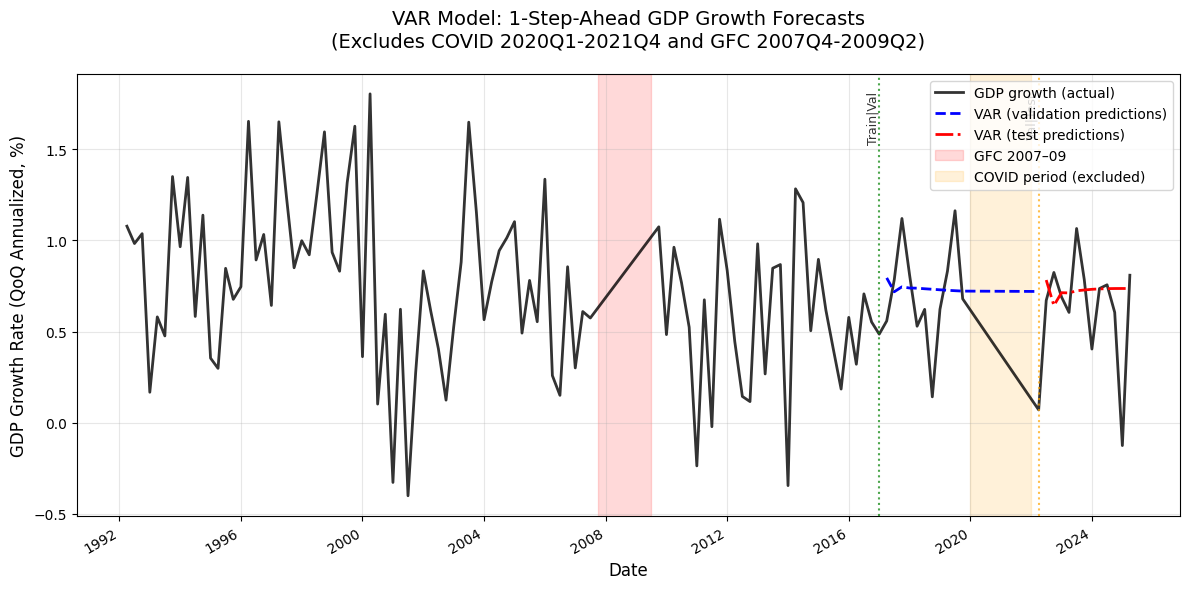


=== PLOTTING DIAGNOSTICS ===
Truth data range: 1992-04-01 00:00:00 to 2025-04-01 00:00:00
Truth data points: 116
Validation predictions: 12 points
Validation RMSE: 0.323
Test predictions: 12 points
Test RMSE: 0.296

  Gap after 2009-10-01 00:00:00: 823 days 00:00:00
  Gap after 2022-04-01 00:00:00: 913 days 00:00:00


In [ ]:
# --- Use the same filtered data that your models were trained on ---
# Instead of trying to use df_t (which may include omitted periods), 
# reconstruct the truth series from your actual train/val/test splits
y_all_filtered = pd.concat([df_tr[y_name], df_va[y_name], df_te[y_name]])

# --- Ensure predictions align with the correct time periods ---
# Make sure your prediction DataFrames have the right indices
print("Checking alignment:")
print(f"var_val data range: {var_val.index.min()} to {var_val.index.max()}")
print(f"var_val predictions range: {var_val_pred_all.index.min()} to {var_val_pred_all.index.max()}")
print(f"var_test data range: {var_test.index.min()} to {var_test.index.max()}")
print(f"var_test predictions range: {var_test_pred_all.index.min()} to {var_test_pred_all.index.max()}")

# --- Create plotting data that excludes omitted periods entirely ---
def qwindow_to_ts(start_q: str, end_q: str):
    s = pd.Period(start_q, freq="Q-DEC").start_time
    e = pd.Period(end_q, freq="Q-DEC").end_time
    return s, e

# Create events list (keep gap=False for all since we're excluding the data entirely)
events = [
    {"label": "GFC 2007–09", "start": "2007Q4", "end": "2009Q2", "color": "red", "alpha": 0.15},
    {"label": "COVID period (excluded)", "start": "2020Q1", "end": "2021Q4", "color": "orange", "alpha": 0.15},
]

# --- Fixed plotting function ---
fig, ax = plt.subplots(figsize=(12, 6))

# Plot truth series (using filtered data that matches your model training)
y_all_filtered.plot(ax=ax, linewidth=2.0, label="GDP growth (actual)", color='black', alpha=0.8)

# Plot VAR predictions - ensure they exist and have correct indices
if 'var_val_pred_all' in locals() and y_name in var_val_pred_all.columns:
    var_val_pred_all[y_name].plot(ax=ax, linewidth=2.0, linestyle="--", 
                                  label="VAR (validation predictions)", color='blue')

if 'var_test_pred_all' in locals() and y_name in var_test_pred_all.columns:
    var_test_pred_all[y_name].plot(ax=ax, linewidth=2.0, linestyle="-.", 
                                   label="VAR (test predictions)", color='red')

# --- Only shade periods that might still appear in your data ---
for ev in events:
    s, e = qwindow_to_ts(ev["start"], ev["end"])
    # Only shade if the period intersects with your actual data range
    data_start = y_all_filtered.index.min()
    data_end = y_all_filtered.index.max()
    
    if s <= data_end and e >= data_start:
        ax.axvspan(max(s, data_start), min(e, data_end), 
                   color=ev.get("color", "gray"), 
                   alpha=ev.get("alpha", 0.15), 
                   label=ev["label"], zorder=0)

# --- Add train/val/test boundaries with better positioning ---
if len(df_tr) > 0:
    train_end_date = df_tr.index[-1]
    ax.axvline(train_end_date, color='green', linestyle=':', linewidth=1.5, alpha=0.7)
    
if len(df_va) > 0:
    val_end_date = df_va.index[-1]  
    ax.axvline(val_end_date, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)

# Add text annotations for splits
ylim = ax.get_ylim()
y_pos = ylim[1] * 0.95  # Position near top of plot

if len(df_tr) > 0:
    ax.text(train_end_date, y_pos, "Train|Val", rotation=90, 
            va="top", ha="right", fontsize=9, alpha=0.8)
            
if len(df_va) > 0:
    ax.text(val_end_date, y_pos, "Val|Test", rotation=90, 
            va="top", ha="right", fontsize=9, alpha=0.8)

ax.set_title("VAR Model: 1-Step-Ahead GDP Growth Forecasts\n(Excludes COVID 2020Q1-2021Q4 and GFC 2007Q4-2009Q2)", 
             fontsize=14, pad=20)
ax.set_ylabel("GDP Growth Rate (QoQ, %)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)

# Remove duplicate labels from legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- CHANGE 8: Add diagnostic information ---
print("\n=== PLOTTING DIAGNOSTICS ===")
print(f"Truth data range: {y_all_filtered.index.min()} to {y_all_filtered.index.max()}")
print(f"Truth data points: {len(y_all_filtered)}")

if 'var_val_pred_all' in locals():
    print(f"Validation predictions: {len(var_val_pred_all)} points")
    val_rmse = rmse(var_val[y_name], var_val_pred_all[y_name])
    print(f"Validation RMSE: {val_rmse:.3f}")

if 'var_test_pred_all' in locals():
    print(f"Test predictions: {len(var_test_pred_all)} points")  
    test_rmse = rmse(var_test[y_name], var_test_pred_all[y_name])
    print(f"Test RMSE: {test_rmse:.3f}")

# Check for any data gaps
date_diff = y_all_filtered.index.to_series().diff()
large_gaps = date_diff[date_diff > pd.Timedelta(days=120)]  # More than ~1 quarter
if len(large_gaps) > 0:
    print(f"\nWarning: Found {len(large_gaps)} large gaps in data:")
    for gap_date, gap_size in large_gaps.items():
        print(f"  Gap after {gap_date}: {gap_size}")

# 2. Forecasting with LSTM

In [66]:
# =========================
# LSTM for GDP growth (exclude GFC + COVID)
# =========================
import numpy as np
import pandas as pd
import torch, torch.nn as nn
from sklearn.preprocessing import StandardScaler

# ---- 0) Config ----
y_name = "GDPC1"  # GDP growth series name in df_t (QoQ annualized log growth)
ORIGINAL_FEATURES = [
    "HOUST","PERMIT","UMCSENT","T10Y3M","DCOILWTICO","INDPRO",
    "RSXFS","PAYEMS","UNRATE","BAA10Y","FEDFUNDS","M2SL"
]
LOOKBACK = 8
HID = 64
LAYERS = 2
DROPOUT = 0.30
LR = 1e-3
WEIGHT_DECAY = 1e-3
EPOCHS = 400
PATIENCE = 20
BATCH = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- 1) Remove GFC + COVID quarters from the transformed panel ----
def drop_windows(df: pd.DataFrame, windows: list[tuple[str,str]]) -> pd.DataFrame:
    p = df.index.to_period("Q")
    keep = pd.Series(True, index=df.index)
    for start_q, end_q in windows:
        s, e = pd.Period(start_q, "Q"), pd.Period(end_q, "Q")
        keep &= ~((p >= s) & (p <= e))
    return df.loc[keep].copy()

windows = [("2007Q4","2009Q2"), ("2020Q1","2021Q4")]
df_ex = drop_windows(df_t, windows)

# Keep only variables that exist in df_ex
X_names = [c for c in ORIGINAL_FEATURES if c in df_ex.columns]
FEATURES = [y_name] + X_names

# ---- 2) Time split (80/10/10) ----
n = len(df_ex)
tr = int(0.8*n); va = int(0.9*n)
df_tr, df_va, df_te = df_ex.iloc[:tr], df_ex.iloc[tr:va], df_ex.iloc[va:]
print(f"Split sizes: train={len(df_tr)}, val={len(df_va)}, test={len(df_te)}")

# ---- 3) Scale (fit on train only) ----
scaler = StandardScaler().fit(df_tr[FEATURES].values)

def scale(df):
    vals = scaler.transform(df[FEATURES].values)
    return pd.DataFrame(vals, index=df.index, columns=FEATURES)

s_tr, s_va, s_te = scale(df_tr), scale(df_va), scale(df_te)

# ---- 4) Build sequences WITHOUT crossing gaps (contiguity check) ----
def make_seq_contiguous(sdf: pd.DataFrame, lookback=8, target_col=y_name):
    X, y, idx = [], [], []
    arr = sdf.values
    pidx = sdf.index.to_period("Q").asi8  # integer quarter ordinals
    tgt = sdf.columns.get_loc(target_col)
    for i in range(lookback, len(sdf)):
        # ensure the last (lookback+1) timestamps are consecutive quarters
        w = pidx[i-lookback:i+1]
        if np.all(np.diff(w) == 1):
            X.append(arr[i-lookback:i, :])
            y.append(arr[i, tgt])
            idx.append(sdf.index[i])
    X = np.asarray(X, np.float32)
    y = np.asarray(y, np.float32).reshape(-1,1)
    return X, y, pd.Index(idx)

# sequences for each split; prepend tails to preserve context at boundaries
Xtr, Ytr, Itr = make_seq_contiguous(s_tr, LOOKBACK)
Xva, Yva, Iva = make_seq_contiguous(pd.concat([s_tr.tail(LOOKBACK), s_va]), LOOKBACK)
Xte, Yte, Ite = make_seq_contiguous(pd.concat([s_tr.tail(LOOKBACK), s_va, s_te]), LOOKBACK)

def to_tensor(x,y): return torch.from_numpy(x).to(device), torch.from_numpy(y).to(device)
Xtr_t, Ytr_t = to_tensor(Xtr, Ytr)
Xva_t, Yva_t = to_tensor(Xva, Yva)
Xte_t, Yte_t = to_tensor(Xte, Yte)

print(f"Batches: train={Xtr_t.shape}, val={Xva_t.shape}, test={Xte_t.shape}")

Device: cuda
Split sizes: train=92, val=12, test=12
Batches: train=torch.Size([76, 8, 13]), val=torch.Size([11, 8, 13]), test=torch.Size([16, 8, 13])


In [67]:
# ---- 5) LSTM with dropout ----
class LSTM1Step(nn.Module):
    def __init__(self, d_in, d_hid=64, layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(d_in, d_hid, num_layers=layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.fc   = nn.Linear(d_hid, 1)
    def forward(self, x):
        out, _ = self.lstm(x)     # [B,T,H]
        last = out[:, -1, :]      # [B,H]
        return self.fc(last)      # [B,1]

model = LSTM1Step(d_in=len(FEATURES), d_hid=HID, layers=LAYERS, dropout=DROPOUT).to(device)
crit  = nn.MSELoss()
opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def batches(X, Y, bs=32):
    n = X.shape[0]; idx = np.random.permutation(n)
    for i in range(0, n, bs):
        j = idx[i:i+bs]; yield X[j], Y[j]

best, wait, best_state = float("inf"), 0, None
for ep in range(1, EPOCHS+1):
    # train
    model.train(); tl = 0.0
    for xb, yb in batches(Xtr_t, Ytr_t, BATCH):
        opt.zero_grad()
        pred = model(xb)
        loss = crit(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tl += loss.item() * xb.size(0)
    tl /= max(1, Xtr_t.size(0))
    # val
    model.eval()
    with torch.no_grad():
        vl = crit(model(Xva_t), Yva_t).item()
    if ep % 25 == 0 or ep == 1:
        print(f"Epoch {ep:3d} | train {tl:.4f} | val {vl:.4f}")
    if vl + 1e-6 < best:
        best, wait = vl, 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {ep}")
            break

# load best weights
if best_state is not None:
    model.load_state_dict(best_state)

# ---- 6) Inverse-transform predictions & evaluate ----
tgt_idx = FEATURES.index(y_name)
tgt_mean = scaler.mean_[tgt_idx]
tgt_std  = scaler.scale_[tgt_idx]

def inv_target(y_scaled: np.ndarray) -> np.ndarray:
    return (y_scaled.reshape(-1) * tgt_std) + tgt_mean

with torch.no_grad():
    yva_hat = inv_target(model(Xva_t).cpu().numpy())
    yte_hat = inv_target(model(Xte_t).cpu().numpy())

y_va_true = df_ex.loc[Iva, y_name].values
y_te_true = df_ex.loc[Ite, y_name].values

def rmse_vec(a,b): 
    a,b = np.asarray(a,float), np.asarray(b,float)
    return float(np.sqrt(np.mean((a-b)**2)))

print(f"[LSTM dropout] GDP growth RMSE | Val: {rmse_vec(y_va_true, yva_hat):.3f} | Test: {rmse_vec(y_te_true, yte_hat):.3f}")

Epoch   1 | train 1.0341 | val 0.3459
Early stopping at epoch 21
[LSTM dropout] GDP growth RMSE | Val: 0.271 | Test: 0.314


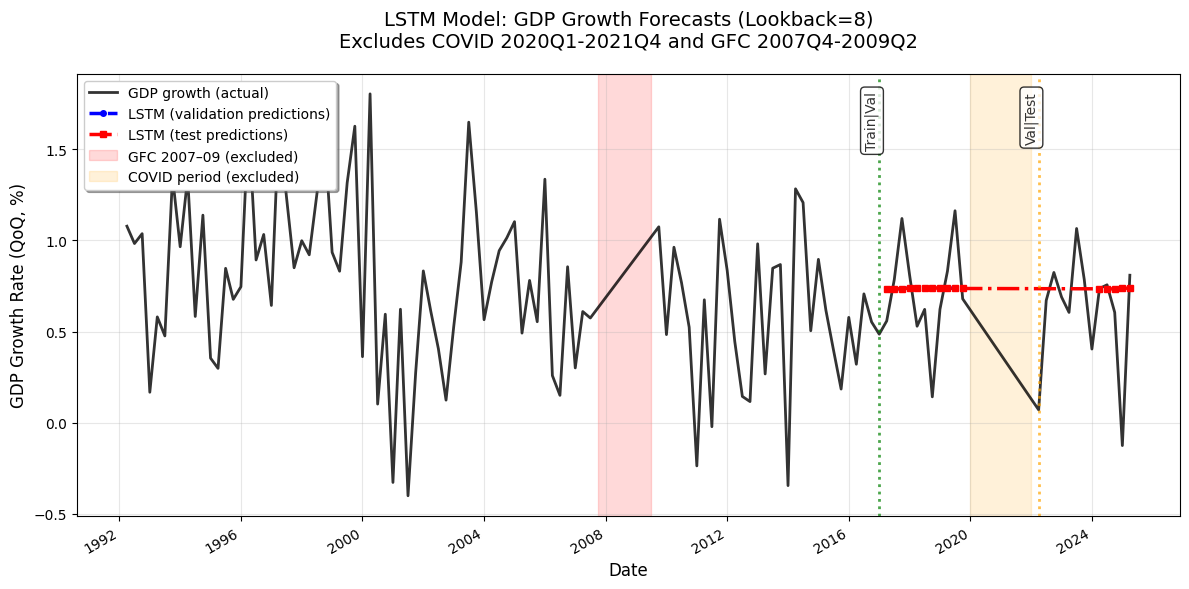


=== LSTM PLOTTING DIAGNOSTICS ===
Truth data range: 1992-04-01 00:00:00 to 2025-04-01 00:00:00
Truth data points: 116
Validation predictions: 11 points from 2017-04-01 00:00:00 to 2019-10-01 00:00:00
Test predictions: 16 points from 2017-04-01 00:00:00 to 2025-04-01 00:00:00
Validation RMSE: 0.271
Test RMSE: 0.314

Sequence details:
Lookback window: 8 quarters
Features used: 13 (['GDPC1', 'HOUST', 'PERMIT', 'UMCSENT', 'T10Y3M', 'DCOILWTICO', 'INDPRO', 'RSXFS', 'PAYEMS', 'UNRATE', 'BAA10Y', 'FEDFUNDS', 'M2SL'])
Training sequences: (76, 8, 13)
Validation sequences: (11, 8, 13)
Test sequences: (16, 8, 13)

Found 2 large gaps in LSTM training data:
  Gap after 2009-10-01 00:00:00: 823 days 00:00:00
  Gap after 2022-04-01 00:00:00: 913 days 00:00:00

=== PERFORMANCE SUMMARY ===
LSTM Validation RMSE: 0.271
LSTM Test RMSE: 0.314
Validation predictions cover: 2017Q2 to 2019Q4
Test predictions cover: 2017Q2 to 2025Q2


In [68]:
# =========================
# LSTM PLOTTING SECTION
# =========================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Create prediction DataFrames with proper indices ---
# Convert predictions back to pandas Series with correct timestamps
va_pred_series = pd.Series(yva_hat, index=Iva, name=y_name)
te_pred_series = pd.Series(yte_hat, index=Ite, name=y_name)

# Create truth series from the excluded dataset (matches what LSTM was trained on)
y_all_lstm = df_ex[y_name]

# --- Events configuration ---
def qwindow_to_ts(start_q: str, end_q: str):
    s = pd.Period(start_q, freq="Q-DEC").start_time
    e = pd.Period(end_q, freq="Q-DEC").end_time
    return s, e

events = [
    {"label": "GFC 2007–09 (excluded)", "start": "2007Q4", "end": "2009Q2", "color": "red", "alpha": 0.15},
    {"label": "COVID period (excluded)", "start": "2020Q1", "end": "2021Q4", "color": "orange", "alpha": 0.15},
]

# --- Create the plot ---
fig, ax = plt.subplots(figsize=(12, 6))

# Plot truth series (using excluded data that matches LSTM training)
y_all_lstm.plot(ax=ax, linewidth=2.0, label="GDP growth (actual)", color='black', alpha=0.8)

# Plot LSTM predictions
va_pred_series.plot(ax=ax, linewidth=2.5, linestyle="--", 
                   label="LSTM (validation predictions)", color='blue', marker='o', markersize=4)

te_pred_series.plot(ax=ax, linewidth=2.5, linestyle="-.", 
                   label="LSTM (test predictions)", color='red', marker='s', markersize=4)

# --- Shade excluded periods (these won't appear in data but show where they would be) ---
for ev in events:
    s, e = qwindow_to_ts(ev["start"], ev["end"])
    # Only shade if the period would intersect with our extended data range
    data_start = y_all_lstm.index.min()
    data_end = y_all_lstm.index.max()
    
    # Extend range to show where excluded periods would be
    extended_start = min(data_start, s)
    extended_end = max(data_end, e)
    
    if s <= extended_end and e >= extended_start:
        ax.axvspan(s, e, color=ev.get("color", "gray"), 
                   alpha=ev.get("alpha", 0.15), 
                   label=ev["label"], zorder=0)

# --- Add train/val/test boundaries ---
if len(df_tr) > 0:
    train_end_date = df_tr.index[-1]
    ax.axvline(train_end_date, color='green', linestyle=':', linewidth=2, alpha=0.7)
    
if len(df_va) > 0:
    val_end_date = df_va.index[-1]  
    ax.axvline(val_end_date, color='orange', linestyle=':', linewidth=2, alpha=0.7)

# Add text annotations for splits
ylim = ax.get_ylim()
y_pos = ylim[1] * 0.95

if len(df_tr) > 0:
    ax.text(train_end_date, y_pos, "Train|Val", rotation=90, 
            va="top", ha="right", fontsize=10, alpha=0.8, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            
if len(df_va) > 0:
    ax.text(val_end_date, y_pos, "Val|Test", rotation=90, 
            va="top", ha="right", fontsize=10, alpha=0.8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# --- Enhanced formatting ---
ax.set_title(f"LSTM Model: GDP Growth Forecasts (Lookback={LOOKBACK})\n" +
             f"Excludes COVID 2020Q1-2021Q4 and GFC 2007Q4-2009Q2", 
             fontsize=14, pad=20)
ax.set_ylabel("GDP Growth Rate (QoQ, %)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)

# Remove duplicate labels from legend and organize better
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left', 
          frameon=True, fancybox=True, shadow=True)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- LSTM-specific diagnostics ---
print("\n=== LSTM PLOTTING DIAGNOSTICS ===")
print(f"Truth data range: {y_all_lstm.index.min()} to {y_all_lstm.index.max()}")
print(f"Truth data points: {len(y_all_lstm)}")
print(f"Validation predictions: {len(va_pred_series)} points from {va_pred_series.index.min()} to {va_pred_series.index.max()}")
print(f"Test predictions: {len(te_pred_series)} points from {te_pred_series.index.min()} to {te_pred_series.index.max()}")

# RMSE calculations (already computed in your code)
val_rmse = rmse_vec(y_va_true, yva_hat)
test_rmse = rmse_vec(y_te_true, yte_hat)
print(f"Validation RMSE: {val_rmse:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")

# Check sequence alignment
print(f"\nSequence details:")
print(f"Lookback window: {LOOKBACK} quarters")
print(f"Features used: {len(FEATURES)} ({FEATURES})")
print(f"Training sequences: {Xtr.shape}")
print(f"Validation sequences: {Xva.shape}")
print(f"Test sequences: {Xte.shape}")

# Check for any data gaps in the excluded dataset
date_diff = y_all_lstm.index.to_series().diff()
large_gaps = date_diff[date_diff > pd.Timedelta(days=120)]  # More than ~1 quarter
if len(large_gaps) > 0:
    print(f"\nFound {len(large_gaps)} large gaps in LSTM training data:")
    for gap_date, gap_size in large_gaps.items():
        print(f"  Gap after {gap_date}: {gap_size}")
else:
    print("\nNo large gaps found in LSTM training data (good!)")

# Performance comparison summary
print(f"\n=== PERFORMANCE SUMMARY ===")
print(f"LSTM Validation RMSE: {val_rmse:.3f}")
print(f"LSTM Test RMSE: {test_rmse:.3f}")

# Prediction coverage
val_start_q = pd.Period(va_pred_series.index.min(), freq='Q')
val_end_q = pd.Period(va_pred_series.index.max(), freq='Q')
test_start_q = pd.Period(te_pred_series.index.min(), freq='Q')
test_end_q = pd.Period(te_pred_series.index.max(), freq='Q')

print(f"Validation predictions cover: {val_start_q} to {val_end_q}")
print(f"Test predictions cover: {test_start_q} to {test_end_q}")

In [ ]:
import pandas as pd
import numpy as np

# y_name is your GDP growth series in *annualized percent* units (400*log(q/q-1))
y_tr = df_tr[y_name].dropna()
y_va = df_va[y_name].dropna()
y_te = df_te[y_name].dropna()
y_all = pd.concat([y_tr, y_va, y_te])

def stds_quarterly_and_annualized(y_ann: pd.Series, label: str):
    # Convert to non-annualized quarterly percent by dividing by 4
    y_qoq = y_ann / 4.0
    sd_qoq = float(y_qoq.std(ddof=1))     # sample std of quarterly growth (percentage points)
    sd_ann = float(y_ann.std(ddof=1))     # sample std of annualized growth (percentage points)
    print(f"{label:>6s} | n={len(y_ann):3d} | SD q/q = {sd_qoq:.3f} pp | SD annualized = {sd_ann:.3f} pp")
    return sd_qoq, sd_ann

sd_tr   = stds_quarterly_and_annualized(y_tr,  "Train")
sd_val  = stds_quarterly_and_annualized(y_va,  "Val")
sd_test = stds_quarterly_and_annualized(y_te,  "Test")
sd_all  = stds_quarterly_and_annualized(y_all, "All")

 Train | n= 92 | SD q/q = 0.116 pp | SD annualized = 0.463 pp
   Val | n= 12 | SD q/q = 0.082 pp | SD annualized = 0.328 pp
  Test | n= 12 | SD q/q = 0.073 pp | SD annualized = 0.291 pp
   All | n=116 | SD q/q = 0.109 pp | SD annualized = 0.434 pp
